# Chapter 9: Comparisons, Masks, and Boolean Logic (NumPy)

## 9.1 Example: Counting Rainy Days

In [3]:
import numpy as np
from vega_datasets import data

rainfall_mm = np.array(data.seattle_weather().set_index('date')['precipitation']['2015'])
len(rainfall_mm)

365

* Visualization

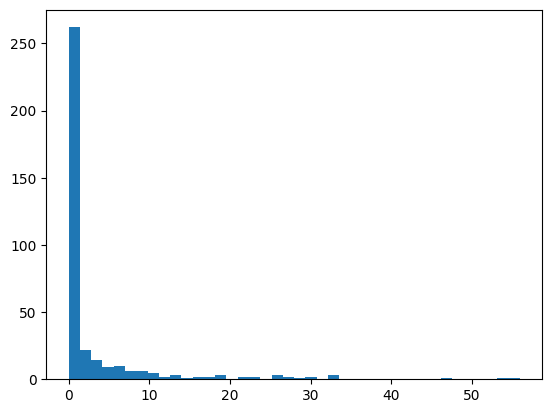

In [4]:
import matplotlib.pyplot as plt

plt.hist(rainfall_mm, 40)
plt.show()

## 9.2 Comparison Operators as Ufuncs

NumPy는 비교 연산자(<, >, ==, !=, <=, >=)를 element-wise ufunc로 구현합니다.

In [5]:
import numpy as np

x = np.array([1, 2, 3, 4, 5])

print(x < 3)
print(x > 3)
print(x <= 3)
print(x >= 3)
print(x != 3)
print(x == 3)

[ True  True False False False]
[False False False  True  True]
[ True  True  True False False]
[False False  True  True  True]
[ True  True False  True  True]
[False False  True False False]


2D array example

In [10]:
rng = np.random.default_rng(seed=1701)
x = rng.integers(10, size=(3, 4))

print(x)
print(x < 6)

[[9 4 0 3]
 [8 6 3 1]
 [3 7 4 0]]
[[False  True  True  True]
 [False False  True  True]
 [ True False  True  True]]


## 9.3 Working with Boolean Arrays

Counting numbers

In [13]:
# np.count_nonzero() 사용
print(np.count_nonzero(x < 6))

# np.sum() 사용 (True=1, False=0)
print(np.sum(x < 6))

# 행별로 세기
print(np.sum(x < 6, axis=1))

8
8
[3 2 3]


np.any() / np.all()

In [16]:
print(np.any(x > 8))    # 하나라도 8보다 크면 True
print(np.any(x < 0))    # 하나라도 0보다 작으면 True
print(np.all(x < 10))   # 모두 10보다 작으면 True
print(np.all(x == 6))   # 모두 6이면 True

True
False
True
False


## 9.4 Boolean Operators

Python의 비트 연산자(&, |, ^, ~)는 NumPy에서 element-wise Boolean 연산으로 동작합니다.

In [23]:
# 10mm보다 크고 20mm보다 작은 날
np.sum((rainfall_mm > 10) & (rainfall_mm < 20))

# De Morgan's laws 사용
np.sum(~(rainfall_mm <= 10) | (rainfall_mm >= 20))

# Examples
print("Number days without rain:", np.sum(rainfall_mm == 0))
print("Number days with rain:", np.sum(rainfall_mm != 0))
print("Days with more than 10 mm:", np.sum(rainfall_mm > 10))
print("Rainy days with < 5mm:", np.sum((rainfall_mm > 0) & (rainfall_mm < 5)))

Number days without rain: 221
Number days with rain: 144
Days with more than 10 mm: 34
Rainy days with < 5mm: 83


## 9.5 Boolean Arrays as Masks

In [ ]:
x = np.array([[9, 4, 0, 3],
              [8, 6, 3, 1],
              [3, 7, 4, 0]])

# 5보다 작은 값만 선택
print(x[x < 5])

# rain example
rainy = (rainfall_mm > 0)
days = np.arange(365)
summer = (days > 172) & (days < 262)

print("Median precip on rainy days:", np.median(rainfall_mm[rainy]))
print("Median precip on summer days:", np.median(rainfall_mm[summer]))
print("Max precip on summer days:", np.max(rainfall_mm[summer]))
print("Median precip on non-summer rainy days:", np.median(rainfall_mm[rainy & ~summer]))

[4 0 3 3 1 3 4 0]
Median precip on rainy days: 3.8
Median precip on summer days: 0.0
Max precip on summer days: 32.5
Median precip on non-summer rainy days: 4.1
